In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from scipy.stats import multivariate_normal
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from vae.models import GaussVAE
from vae.trainers import GaussVAETrainer
from vae.neural_networks import EncoderGaussVAE, DecoderGaussVAE
from data.simple_geometry import (
    Circle, Square, Triangle, Superposition2D, Segment
)
from data.transformations import ScaledTranslation, Rotation
from pathlib import Path

# Data

In [2]:
size = 10000
sigma = 0.05

triangle_1, triangle_2, triangle_3 = Triangle(), Triangle(), Triangle()
dataset = Superposition2D([
    (triangle_1, ScaledTranslation(alpha=1, beta=[1/2, np.sqrt(3)/6])),
    (triangle_2, ScaledTranslation(alpha=1, beta=[0, -np.sqrt(3)/3])),
    (triangle_3, ScaledTranslation(alpha=1, beta=[1, -np.sqrt(3)/3])),
])
dataset.sample(size, sigma)

In [3]:
rotation = Rotation(theta=np.pi)

In [4]:
rotation.apply(dataset)

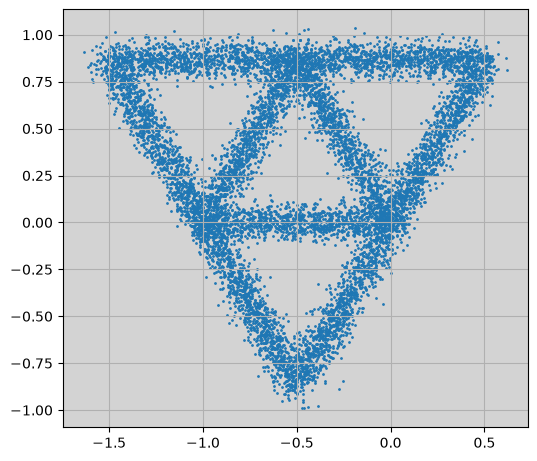

In [5]:
dataset.plot()
plt.show()

# Model

In [6]:
data_dim = 2
latent_dim = 2

encoder = EncoderGaussVAE(data_dim, latent_dim)
decoder = DecoderGaussVAE(data_dim, latent_dim)
encoder_decoder = nn.ModuleDict({
    "encoder" : encoder, 
    "decoder" : decoder
})

In [7]:
sigma = 0.05
model = GaussVAE(encoder, decoder, sigma)

# Training

In [8]:
batch_size = 8
lr = 1e-3

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
optimizer = Adam(encoder_decoder.parameters(), lr=lr)
trainer = GaussVAETrainer(model, dataloader, optimizer)

In [9]:
n_epochs = 10
n_latent = 64
log_dir = Path("/Users/aymanchaouki/Documents/Personal/projects/generative-models/runs/")
n_log = 1

trainer.train(n_epochs, n_latent, log_dir, n_log)

# Evaluation

In [10]:
n_samples = 10000
X_sampled = model.sample(n_samples)

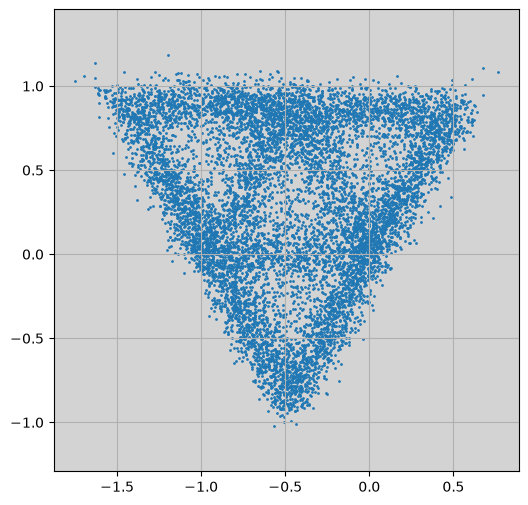

In [13]:
fig_size = (6, 6)
fig, ax = plt.subplots(1, 1, figsize=fig_size)
ax.scatter(X_sampled[:, 0], X_sampled[:, 1], s=1)
ax.grid()

ax.set_facecolor("lightgrey")
plt.axis("equal")
plt.show()